# Preprocessing, Feature Engineering & Modellierung

**Einleitung:**

Dieses Notebook befasst sich mit der Analyse und Vorhersage von Retouren im E-Commerce auf Basis des Superstore-Datensatzes.

Die Datengrundlage bilden Transaktionsdaten, die Informationen zu Bestellungen, Produktkategorien und Regionen enthalten und mit den entsprechenden Retourenmeldungen verknüpft wurden. Im Zuge der Datenaufbereitung wurden die relevanten Variablen bereinigt und kategoriale Attribute transformiert, um das Retourenverhalten als Zielvariable zu definieren. Ziel ist es, mithilfe einer Linearen-Regression, eines Entscheidungsbaums und einer KNN-Regression Muster im Retourenverhalten aufzudecken, um an die folgende Forschungsfrage anzuschließen:

**Forschungsfrage:**

`Unterscheiden sich Retourenraten signifikant zwischen Produktkategorien?`

## Import Packages

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn_qqplot import pplot
import numpy as np
from ydata_profiling import ProfileReport
import random

In [2]:
from scipy import stats
import scipy.stats as stats
import statsmodels.formula.api as smf
from scipy.stats import f_oneway

In [3]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    Normalizer,
    QuantileTransformer,
    MinMaxScaler,
    KBinsDiscretizer,
    PolynomialFeatures,
    FunctionTransformer,
    PowerTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor


from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import numpy as np

## File Directories

In [187]:
INPUT_DIR = os.path.join("../input")

In [189]:
OUTPUT_DIR = os.path.join("../output")

In [191]:
DOC_DIR = os.path.join("../documents")

In [192]:
FILE_DIR = os.path.join("../input")

## Load Data

In [196]:
df_superstore = pd.read_csv(os.path.join(OUTPUT_DIR,"merged_superstore_dfv2.csv"))

## Prepare

In [199]:
df_superstore["num_returned"] = (df_superstore["Returned"] == "Yes").astype(int)

In [201]:
df_superstore = df_superstore.rename(
    columns={
        "shipping-cost": "shipping_cost",
        "Order Date": "order_date",
        "Postal Code": "postal_code",
        "Sub-Category": "sub_category",
        "Product Name": "product_name",
        "Shipping Cost":"shipping_cost",
        "Order Priority": "order_priority",
        "Ship Date": "ship_date",
        "Ship Mode": "ship_mode",
        "Customer Name": "customer_name",
        "Customer ID": "customer_id",
        "Row ID": "row_id",
        "Order ID": "order_id",
        "Product ID": "product_id",
    }
)

In [203]:
df_superstore.columns

Index(['Unnamed: 0', 'row_id', 'order_id', 'order_date', 'ship_date',
       'ship_mode', 'customer_id', 'customer_name', 'Segment', 'City', 'State',
       'Country', 'postal_code', 'Market', 'Region', 'product_id', 'Category',
       'sub_category', 'product_name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'shipping_cost', 'order_priority', 'Returned',
       'order_to_ship_date', 'num_returned'],
      dtype='object')

### Variable Lists

In [206]:
target_col = ["proxy_returnrate"]

In [756]:
cat_features_col = ["Market", "order_priority", "Segment", "Region", "sub_category" ,'City', 'State','Country']

In [526]:
num_features_col = [ "Discount", "order_to_ship_date", "shipping_cost", "num_orders", "order_product_share", "customer_return", "order_month", "cat_discount"]

In [ ]:
col_transform_pipeline = ColumnTransformer(
    [
        ("power_yeo", power_transformer_yeo_pipelines,["Profit"]),
        ("power_boxcox", power_transformer_boxcox_pipelines, ["Quantity", "Sales"]),
        ("onehot_transformer", OneHotEncoder(), ["Market"]),
        ("ordinal_transformer", OrdinalEncoder(), ["order_priority", "cat_discount", "order_to_ship_date", "order_product_share", "order_month", "customer_return"]),
        
        
    ]
)

In [ ]:
"Sales","Profit","Quantity",

## Transform

### Neue Variable

**Note**:

---

- Um mit den Modellen die Retourenwahrscheinlichkeit auf Produktebene vorherzusagen, müssen die folgenden Fragen beantwortet werden:
    - In wie vielen Bestellungen taucht das Produkt auf? -> `num_orders`
    - Wie viele dieser Bestellungen verzeichnen Retouren? -> `num_orders_returned`
- Mit den daraus erstellten Variablen definieren wir unser Target -> `proxy_returnrate` um eine indirekte Retourenrate auf Produktebene zu approximieren.
      


---

#### `num_orders`

In [212]:
pivot_count_orders = df_superstore.pivot_table( values= ["order_id"], index = "product_id", aggfunc="nunique")
pivot_count_orders = pivot_count_orders.reset_index()
pivot_count_orders = pivot_count_orders.rename(columns={1: "num_orders"})
pivot_count_orders

,product_id,order_id
0,FUR-ADV-10000002,2
1,FUR-ADV-10000108,3
2,FUR-ADV-10000183,8
3,FUR-ADV-10000188,5
4,FUR-ADV-10000190,1
...,...,...
10287,TEC-STA-10004181,6
10288,TEC-STA-10004536,5
10289,TEC-STA-10004542,5
10290,TEC-STA-10004834,2


In [214]:
df_superstore = df_superstore.merge(pivot_count_orders[["product_id","order_id"]],how ="left", on="product_id")
df_superstore

,Unnamed: 0,row_id,order_id_x,order_date,ship_date,ship_mode,customer_id,customer_name,Segment,City,...,Sales,Quantity,Discount,Profit,shipping_cost,order_priority,Returned,order_to_ship_date,num_returned,order_id_y
0,0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,...,2309.650,7,0.0,762.1845,933.570,Critical,No,0,0,10
1,1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,...,3709.395,9,0.1,-288.7650,923.630,Critical,Yes,2,1,10
2,2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,...,5175.171,9,0.1,919.9710,915.490,Medium,No,1,0,10
3,3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,...,2892.510,5,0.1,-96.5400,910.160,Medium,No,2,0,4
4,4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,...,2832.960,8,0.0,311.5200,903.040,Critical,No,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51290,51290,29002,IN-2014-62366,2014-06-19,2014-06-19,Same Day,KE-16420,Katrina Edelman,Corporate,Kure,...,65.100,5,0.0,4.5000,0.010,Medium,Yes,0,1,5
51291,51291,35398,US-2014-102288,2014-06-20,2014-06-24,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,Houston,...,0.444,1,0.8,-1.1100,0.010,Medium,No,4,0,4
51292,51292,40470,US-2013-155768,2013-12-02,2013-12-02,Same Day,LB-16795,Laurel Beltran,Home Office,Oxnard,...,22.920,3,0.0,11.2308,0.010,High,No,0,0,8
51293,51293,9596,MX-2012-140767,2012-02-18,2012-02-22,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,...,13.440,2,0.0,2.4000,0.003,Medium,No,4,0,9


In [215]:
df_superstore = df_superstore.rename(
    columns={
        "order_id_y": "num_orders",
    }
)

#### `num_orders_returned`

In [219]:
pivot_sum_returns = df_superstore.pivot_table( values= ["num_returned"], index = "product_id", aggfunc="sum")
pivot_sum_returns = pivot_sum_returns.reset_index()
pivot_sum_returns

,product_id,num_returned
0,FUR-ADV-10000002,0
1,FUR-ADV-10000108,0
2,FUR-ADV-10000183,0
3,FUR-ADV-10000188,0
4,FUR-ADV-10000190,0
...,...,...
10287,TEC-STA-10004181,0
10288,TEC-STA-10004536,0
10289,TEC-STA-10004542,0
10290,TEC-STA-10004834,0


In [220]:
df_superstore = df_superstore.merge(pivot_sum_returns[["product_id","num_returned"]],how ="left", on="product_id")
df_superstore.head(3)

,Unnamed: 0,row_id,order_id_x,order_date,ship_date,ship_mode,customer_id,customer_name,Segment,City,...,Quantity,Discount,Profit,shipping_cost,order_priority,Returned,order_to_ship_date,num_returned_x,num_orders,num_returned_y
0,0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,...,7,0.0,762.1845,933.57,Critical,No,0,0,10,0
1,1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,...,9,0.1,-288.7650,923.63,Critical,Yes,2,1,10,2
2,2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,...,9,0.1,919.9710,915.49,Medium,No,1,0,10,0


In [222]:
df_superstore = df_superstore.rename(
    columns={
        "num_returned_y": "num_orders_returned",
    }
)

#### `proxy_returnrate`

In [226]:
df_superstore["proxy_returnrate"] = df_superstore["num_orders_returned"]/df_superstore["num_orders"]

In [228]:
df_superstore = df_superstore.rename(
    columns={
        "order_id_x": "order_id",
        "num_returned_x": "num_returned",
           }
)

<Axes: xlabel='proxy_returnrate', ylabel='Count'>

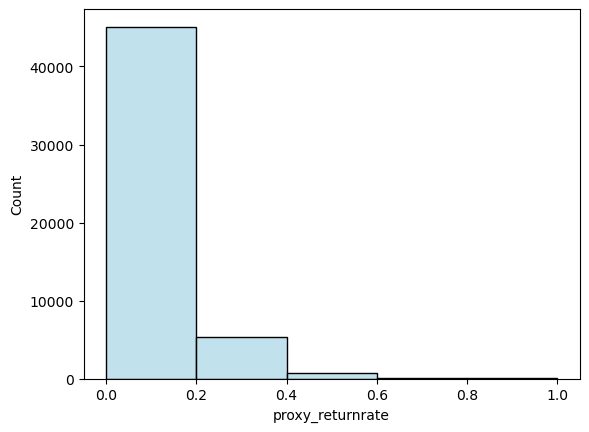

In [229]:
sns.histplot(df_superstore["proxy_returnrate"], bins=5, color="lightblue")

**Note:**

---

- Die Verteilung bildet eine rechtsschiefe Zero-Inflated-Struktur.

---

### Transform `Discount` to category Variable

**Note**:

---

- Im Abschnitt `Verteilung analysieren` fällt auf, dass die Variable `Discount` folgende Probleme aufweist:
    - Die Verteilung ist Zero-Inflated
    - Obwohl die Variable stetiger Natur ist, bilden die Datenpunkte eine diskrete Struktur
- Aus den genannten Gründen konvertieren wir `Discount` zu einer kategorialen Variable mit den Werten:
    - `no_discount`
    - `low_discount`
    - `medium_discount`
    - `high_discount`

---

<Axes: xlabel='Discount', ylabel='Count'>

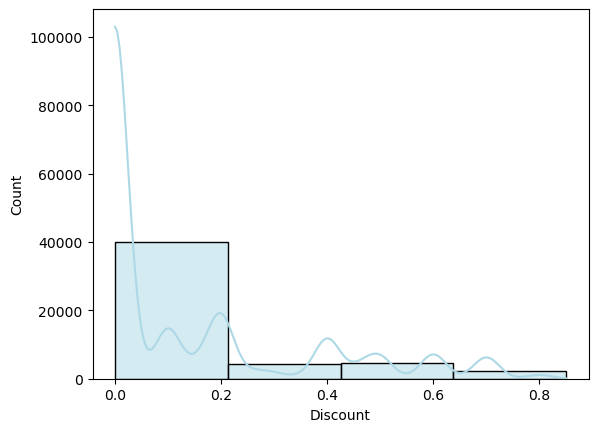

In [235]:
sns.histplot(df_superstore["Discount"], bins = 4, color="lightblue", kde=True)

In [236]:
def set_class(d_value):
    if d_value == 0:
        return "no_discount"
    elif (d_value > 0) & (d_value <= 0.2):
        return "low_discount"
    elif (d_value >= 0.2) & (d_value <= 0.5):
        return "medium_discount"
    else:
        return "high_discount"

In [239]:
df_superstore["cat_discount"] = df_superstore["Discount"].apply(set_class)

In [241]:
df_superstore.columns

Index(['Unnamed: 0', 'row_id', 'order_id', 'order_date', 'ship_date',
       'ship_mode', 'customer_id', 'customer_name', 'Segment', 'City', 'State',
       'Country', 'postal_code', 'Market', 'Region', 'product_id', 'Category',
       'sub_category', 'product_name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'shipping_cost', 'order_priority', 'Returned',
       'order_to_ship_date', 'num_returned', 'num_orders',
       'num_orders_returned', 'proxy_returnrate', 'cat_discount'],
      dtype='object')

In [243]:
cat_discount_value = df_superstore["cat_discount"].value_counts()

<Axes: xlabel='cat_discount'>

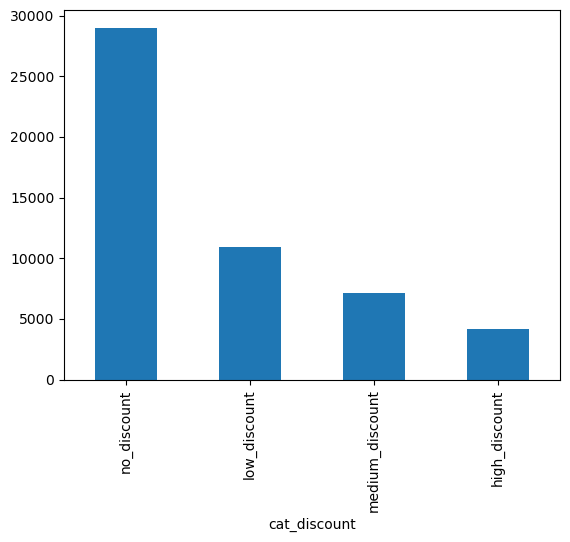

In [245]:
cat_discount_value.plot.bar()

### `customer_returns`

In [248]:
pivot_count_customer_returns = df_superstore.pivot_table( values= ["num_returned"], index = "customer_id", aggfunc="sum")
pivot_count_customer_returns = pivot_count_customer_returns.reset_index()
pivot_count_customer_returns

,customer_id,num_returned
0,AA-10315,5
1,AA-10375,5
2,AA-10480,0
3,AA-10645,1
4,AA-315,0
...,...,...
1585,YS-21880,7
1586,ZC-11910,0
1587,ZC-21910,6
1588,ZD-11925,0


In [250]:
df_superstore = df_superstore.merge(pivot_count_customer_returns[["customer_id","num_returned"]],how ="left", on="customer_id")
df_superstore.head(3)

,Unnamed: 0,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,Segment,City,...,shipping_cost,order_priority,Returned,order_to_ship_date,num_returned_x,num_orders,num_orders_returned,proxy_returnrate,cat_discount,num_returned_y
0,0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,...,933.57,Critical,No,0,0,10,0,0.0,no_discount,8
1,1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,...,923.63,Critical,Yes,2,1,10,2,0.2,low_discount,7
2,2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,...,915.49,Medium,No,1,0,10,0,0.0,low_discount,0


In [289]:
df_superstore.columns

Index(['Unnamed: 0', 'row_id', 'order_id', 'order_date', 'ship_date',
       'ship_mode', 'customer_id', 'customer_name', 'Segment', 'City', 'State',
       'Country', 'postal_code', 'Market', 'Region', 'product_id', 'Category',
       'sub_category', 'product_name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'shipping_cost', 'order_priority', 'Returned',
       'order_to_ship_date', 'num_returned', 'num_orders',
       'num_orders_returned', 'proxy_returnrate', 'cat_discount',
       'customer_return', 'unique_products_in_order', 'order_product_share',
       'order_month'],
      dtype='object')

In [254]:
df_superstore = df_superstore.rename(
    columns={
        "num_returned_x": "num_returned",
        "num_returned_y": "customer_return",
    }
)

#### `unique_products_in_order`

In [259]:
pivot_count_products = df_superstore.pivot_table( values= ["product_id"], index = "order_id", aggfunc="nunique")
pivot_count_products = pivot_count_products.reset_index()
pivot_count_products

,order_id,product_id
0,AE-2011-9160,2
1,AE-2013-1130,2
2,AE-2013-1530,2
3,AE-2014-2840,1
4,AE-2014-3830,6
...,...,...
25030,ZI-2014-7160,3
25031,ZI-2014-7610,2
25032,ZI-2014-9540,1
25033,ZI-2014-9550,2


In [261]:
df_superstore = df_superstore.merge(pivot_count_products[["order_id","product_id"]],how ="left", on="order_id")

In [263]:
df_superstore = df_superstore.rename(
    columns={
        "product_id_x": "product_id",
        "product_id_y": "unique_products_in_order",
           }
)

#### `order_product_share`

In [272]:
df_superstore["order_product_share"] = 1/df_superstore["unique_products_in_order"]

#### `order_month`

In [275]:
df_superstore["order_month"]= pd.to_datetime(df_superstore["order_date"]).dt.month
df_superstore.head(3)

,Unnamed: 0,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,Segment,City,...,order_to_ship_date,num_returned,num_orders,num_orders_returned,proxy_returnrate,cat_discount,customer_return,unique_products_in_order,order_product_share,order_month
0,0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,...,0,0,10,0,0.0,no_discount,8,3,0.333333,7
1,1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,...,2,1,10,2,0.2,low_discount,7,4,0.250000,2
2,2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,...,1,0,10,0,0.0,low_discount,0,5,0.200000,10


### Aufteilung des Datensatzes

In [291]:
train_df, test_df = train_test_split(df_superstore, random_state=42)

## Zusammenhänge zwischen Features und Target untersuchen

### ANOVA

**NOTE:**

---

- Im Folgenden untersuchen wir die Zusammenhänge zwischen den kategorialen Variablen und unserem Target.

- Als Werkzeug nutzen wir ANOVA. Wir vergleichen die Mittelwerte zwischen den Gruppen der kategorialen Variablen gegen den Target `proxy_returnrate`.

- Variablen mit signifikanten Gruppenunterschieden bieten die stärkste Erklärungskraft und werden anhand der P-Werte als Features ausgewählt.

---

##### Kategoriale Variable

In [752]:
def anova(df, var):
    
    kategorien = df[var].unique()
    
    gruppen_liste = [df[df[var] == kat]["proxy_returnrate"] for kat in kategorien]
    
    f_statistic, p_value = f_oneway(*gruppen_liste)
    
    return f_statistic, p_value

In [758]:
for m in cat_features_col:
    merkmal = m

    f_statistic, p_value = anova(train_df, merkmal)

    print(f"{merkmal}: {p_value}")
    print(f"{merkmal}: {f_statistic}")

Market: 0.0
Market: 526.7108615486699
order_priority: 0.6606590041835884
order_priority: 0.5314725992277125
Segment: 0.5503069412251399
Segment: 0.5972883553202899
Region: 0.0
Region: 278.77618432150524
sub_category: 1.6924098664903485e-43
sub_category: 15.515194159294625
City: 5.362281091451683e-292
City: 2.271887815598428
State: 0.0
State: 4.191734013071878
Country: 0.0
Country: 23.85321553211176


### Korrelationsanalyse

In [302]:
num_variables = target_col+num_features_col

In [304]:
train_df[num_variables].corr()

,proxy_returnrate,Quantity,Discount,order_to_ship_date,Sales,Profit,shipping_cost,num_orders,order_product_share,customer_return,order_month
proxy_returnrate,1.000000,0.074873,-0.026089,0.003252,0.023696,0.016860,0.016968,-0.025702,-0.033244,0.207192,0.010091
Quantity,0.074873,1.000000,-0.021811,0.001694,0.305190,0.105851,0.265502,-0.013209,-0.002899,0.110649,0.019607
Discount,-0.026089,-0.021811,1.000000,0.001046,-0.085384,-0.313932,-0.081200,-0.032213,-0.012004,-0.027974,-0.003835
order_to_ship_date,0.003252,0.001694,0.001046,1.000000,-0.004231,0.002847,-0.142271,0.004940,-0.004955,0.014759,0.006904
Sales,0.023696,0.305190,-0.085384,-0.004231,1.000000,0.506613,0.760295,-0.107011,-0.004426,0.028577,-0.000178
Profit,0.016860,0.105851,-0.313932,0.002847,0.506613,1.000000,0.371680,-0.018671,-0.003418,0.019968,-0.000063
shipping_cost,0.016968,0.265502,-0.081200,-0.142271,0.760295,0.371680,1.000000,-0.091829,0.001235,0.021321,-0.000152
num_orders,-0.025702,-0.013209,-0.032213,0.004940,-0.107011,-0.018671,-0.091829,1.000000,-0.004444,-0.023993,-0.001377
order_product_share,-0.033244,-0.002899,-0.012004,-0.004955,-0.004426,-0.003418,0.001235,-0.004444,1.000000,-0.049577,0.002713
customer_return,0.207192,0.110649,-0.027974,0.014759,0.028577,0.019968,0.021321,-0.023993,-0.049577,1.000000,0.023404


### Variationskoeffizient

**NOTE:**

---

Variationskoeffizient:

- Von den selektierten Merkmalen berechnen wir die Variationskoeffizienten der Ausprägungen.



---

In [87]:
def variationskoeffizient_berechnen(numerische_variable):
    var_koef= (train_df[value].std() / train_df[value].mean()) * 100
    
    return var_koef

In [88]:
for s in num_features_col:

    value = s
    
    var_koef_value = variationskoeffizient_berechnen(value)
    
    print(f"{s}: {var_koef_value}")

Quantity: 65.61279367937716
Discount: 148.41373234591285
order_to_ship_date: 43.718473551256345
Sales: 200.54923216453213
Profit: 614.6604068962062
shipping_cost: 217.92694080319
num_orders: 57.597605593494414


## Verteilung analysieren

### Kategoriale Variable

#### `Market`

In [315]:
groupby_market_prr = train_df.groupby("Market")["proxy_returnrate"].mean()

<Axes: xlabel='Market'>

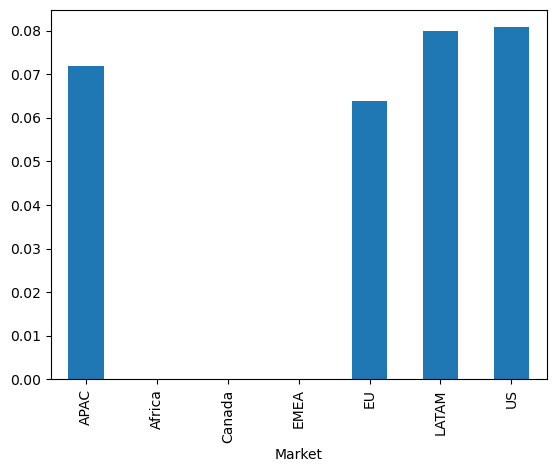

In [317]:
groupby_market_prr.plot.bar()

#### `sub_category`

In [320]:
groupby_sub_category_prr = train_df.groupby("sub_category")["proxy_returnrate"].mean()

<Axes: xlabel='sub_category'>

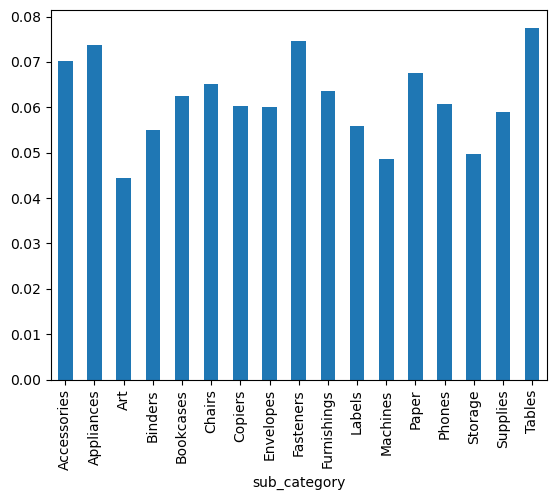

In [322]:
groupby_sub_category_prr.plot.bar()

### Numerische Variable

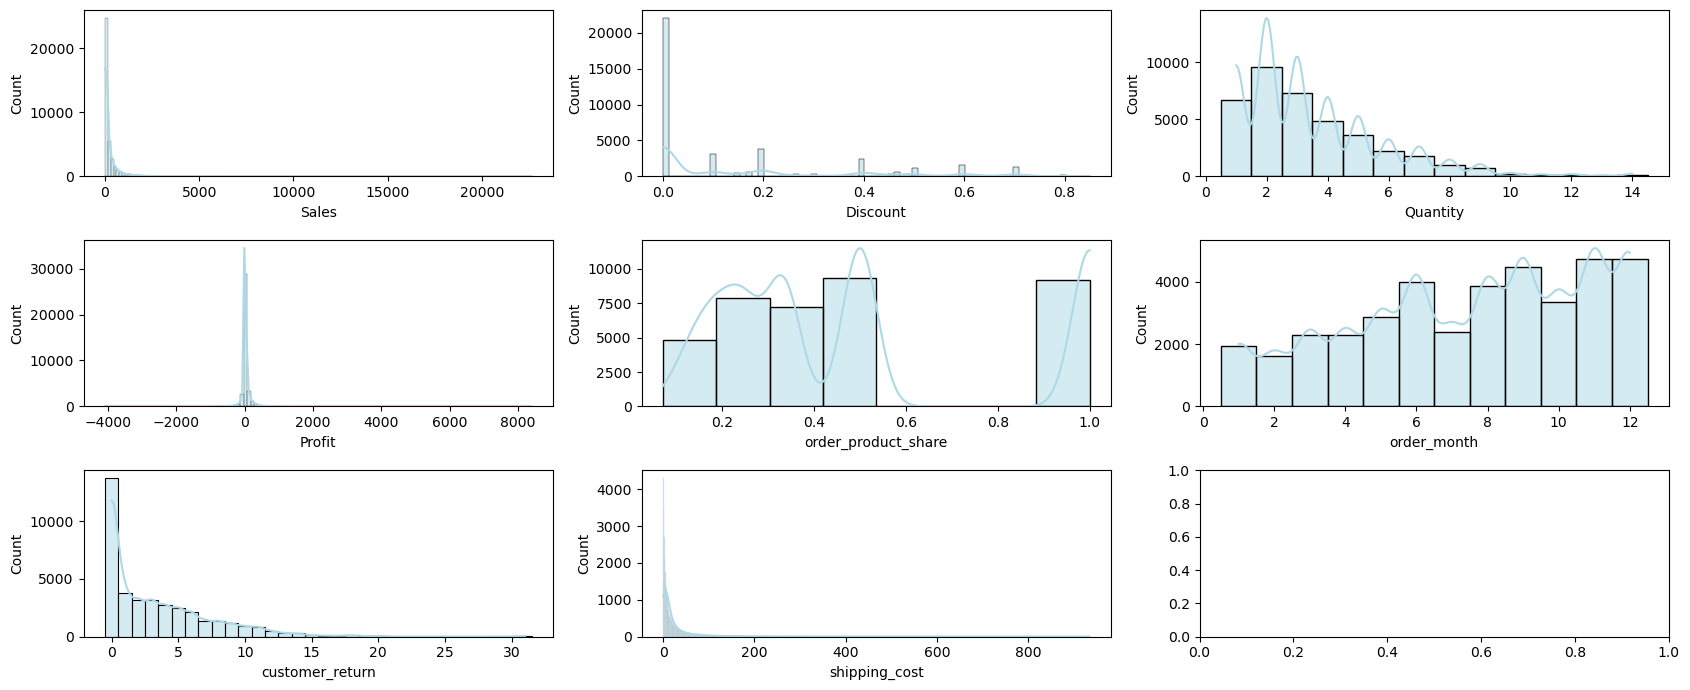

In [532]:
fig, ax = plt.subplots(3,3, figsize=(17, 7))

sns.histplot(train_df["Sales"], ax=ax[0,0], bins=150, color="lightblue", kde=True)
sns.histplot(train_df["Discount"], ax=ax[0,1], color="lightblue", kde=True)
sns.histplot(train_df["Quantity"], discrete=True, ax=ax[0,2], color="lightblue", kde=True)
sns.histplot(train_df["Profit"], ax=ax[1,0], bins = 120, color="lightblue", kde=True)
sns.histplot(train_df["order_product_share"], ax=ax[1,1], bins=8, color="lightblue", kde=True)
sns.histplot(train_df["order_month"], ax=ax[1,2], discrete=True, color="lightblue", kde=True)
sns.histplot(train_df["customer_return"], ax=ax[2,0], discrete=True, color="lightblue", kde=True)
sns.histplot(train_df["shipping_cost"], ax=ax[2,1], discrete=True, color="lightblue", kde=True)

plt.tight_layout()

**Note**:

---

`Sales`:

- Rechtsschiefe Verteilung
- Anwendung von Power-Transformer (Box-Cox)

`Discount`

- Zero-Inflated
- Zeigt eine diskrete Struktur
- Wird zu einer kategorialen Variable transformiert

`Quantity`

- Rechtsschiefe Verteilung
- Anwendung von Power-Transformer (Box-Cox)

`Profit`

- Extreme Spitze am Null-Punkt (Leptokurtosis)
- Symmetrische Verteilung mit einer Glockenkurve
- Anwendung von Power-Transformer (QuantileTransformer)

Im nächsten Abschnitt wollen wir mit Werkzeugen des Feature-Engineerings die schiefen Verteilungen der abhängigen und unabhängigen Variablen sowie das Rauschen in den Varianzen minimieren.

---

## Pipelines

### PowerTransformer: Yeo-Johnson

In [316]:
power_transformer_yeo_pipelines = Pipeline(
    [
        ("power_yeo", PowerTransformer(method="yeo-johnson")),
        ("std_scaler", StandardScaler()),
    ]
)

### PowerTransformer: Box-Cox

In [319]:
power_transformer_boxcox_pipelines = Pipeline(
    [
        ("power_boxcox", PowerTransformer(method="box-cox")),
        ("std_scaler", StandardScaler()),
    ]
)

### QuantileTransformer

In [322]:
quantile_transformer_pipelines = Pipeline(
    [
        ("quantile_transformer", QuantileTransformer()),
        ("std_scaler", StandardScaler()),
    ]
)

### ColumnTransformer

In [324]:
df_superstore.columns

Index(['Unnamed: 0', 'row_id', 'order_id', 'order_date', 'ship_date',
       'ship_mode', 'customer_id', 'customer_name', 'Segment', 'City', 'State',
       'Country', 'postal_code', 'Market', 'Region', 'product_id', 'Category',
       'sub_category', 'product_name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'shipping_cost', 'order_priority', 'Returned',
       'order_to_ship_date', 'num_returned', 'num_orders',
       'num_orders_returned', 'proxy_returnrate', 'cat_discount',
       'customer_return', 'unique_products_in_order', 'order_product_share',
       'order_month'],
      dtype='object')

In [666]:
col_transform_pipeline = ColumnTransformer(
    [
        ("power_yeo", power_transformer_yeo_pipelines,["shipping_cost"]),
        #("power_boxcox", power_transformer_boxcox_pipelines, ["Quantity", "Sales"]),
        ("onehot_transformer", OneHotEncoder(), ["Market", "Segment", "Region", "sub_category"]),
        ("ordinal_transformer", OrdinalEncoder(), ["order_priority", "cat_discount", "order_to_ship_date", "order_product_share", "order_month", "customer_return"]),
        
        
    ]
)

In [647]:
new_num_features = ["Sales","Quantity", "Profit"]

In [649]:
new_cat_features = ["Category", "sub_category", "cat_discount", "order_priority", "Market"]

## Prepare Training-Set

In [668]:
def prepare_for_pipeline(df):
    print("Original shape:", df.shape)
    df = df[cat_features_col + num_features_col + ["proxy_returnrate"]].dropna()
    print("Shape after dropna():", df.shape)
    x = df[cat_features_col + num_features_col]
    y = df[["proxy_returnrate"]]
    print("Shape after feature selection:", x.shape)
    return x, y

### Transform Features

In [671]:
x_train, y_train = prepare_for_pipeline(train_df)

Original shape: (38471, 36)
Shape after dropna(): (38471, 14)
Shape after feature selection: (38471, 13)


In [673]:
x_train_transformed = col_transform_pipeline.fit_transform(x_train)

**Array-Output von der Pipeline in DataFrame konvertieren**

In [676]:
def array_to_df(list_array, col_names):
    
    new_df = pd.DataFrame(list_array, columns=col_names)
    new_df = new_df.reset_index(drop=True)
    
    return new_df

In [678]:
x_col_names = col_transform_pipeline.get_feature_names_out()

In [682]:
x_col_names

array(['power_yeo__shipping_cost', 'onehot_transformer__Market_APAC',
       'onehot_transformer__Market_Africa',
       'onehot_transformer__Market_Canada',
       'onehot_transformer__Market_EMEA', 'onehot_transformer__Market_EU',
       'onehot_transformer__Market_LATAM',
       'onehot_transformer__Market_US',
       'onehot_transformer__Segment_Consumer',
       'onehot_transformer__Segment_Corporate',
       'onehot_transformer__Segment_Home Office',
       'onehot_transformer__Region_Africa',
       'onehot_transformer__Region_Canada',
       'onehot_transformer__Region_Caribbean',
       'onehot_transformer__Region_Central',
       'onehot_transformer__Region_Central Asia',
       'onehot_transformer__Region_EMEA',
       'onehot_transformer__Region_East',
       'onehot_transformer__Region_North',
       'onehot_transformer__Region_North Asia',
       'onehot_transformer__Region_Oceania',
       'onehot_transformer__Region_South',
       'onehot_transformer__Region_Southeast A

In [686]:
x_train_transformed_df = array_to_df(x_train_transformed.toarray(), x_col_names)

In [688]:
x_train_transformed_df.columns

Index(['power_yeo__shipping_cost', 'onehot_transformer__Market_APAC',
       'onehot_transformer__Market_Africa',
       'onehot_transformer__Market_Canada', 'onehot_transformer__Market_EMEA',
       'onehot_transformer__Market_EU', 'onehot_transformer__Market_LATAM',
       'onehot_transformer__Market_US', 'onehot_transformer__Segment_Consumer',
       'onehot_transformer__Segment_Corporate',
       'onehot_transformer__Segment_Home Office',
       'onehot_transformer__Region_Africa',
       'onehot_transformer__Region_Canada',
       'onehot_transformer__Region_Caribbean',
       'onehot_transformer__Region_Central',
       'onehot_transformer__Region_Central Asia',
       'onehot_transformer__Region_EMEA', 'onehot_transformer__Region_East',
       'onehot_transformer__Region_North',
       'onehot_transformer__Region_North Asia',
       'onehot_transformer__Region_Oceania',
       'onehot_transformer__Region_South',
       'onehot_transformer__Region_Southeast Asia',
       'onehot_

<Axes: xlabel='power_yeo__Profit', ylabel='Count'>

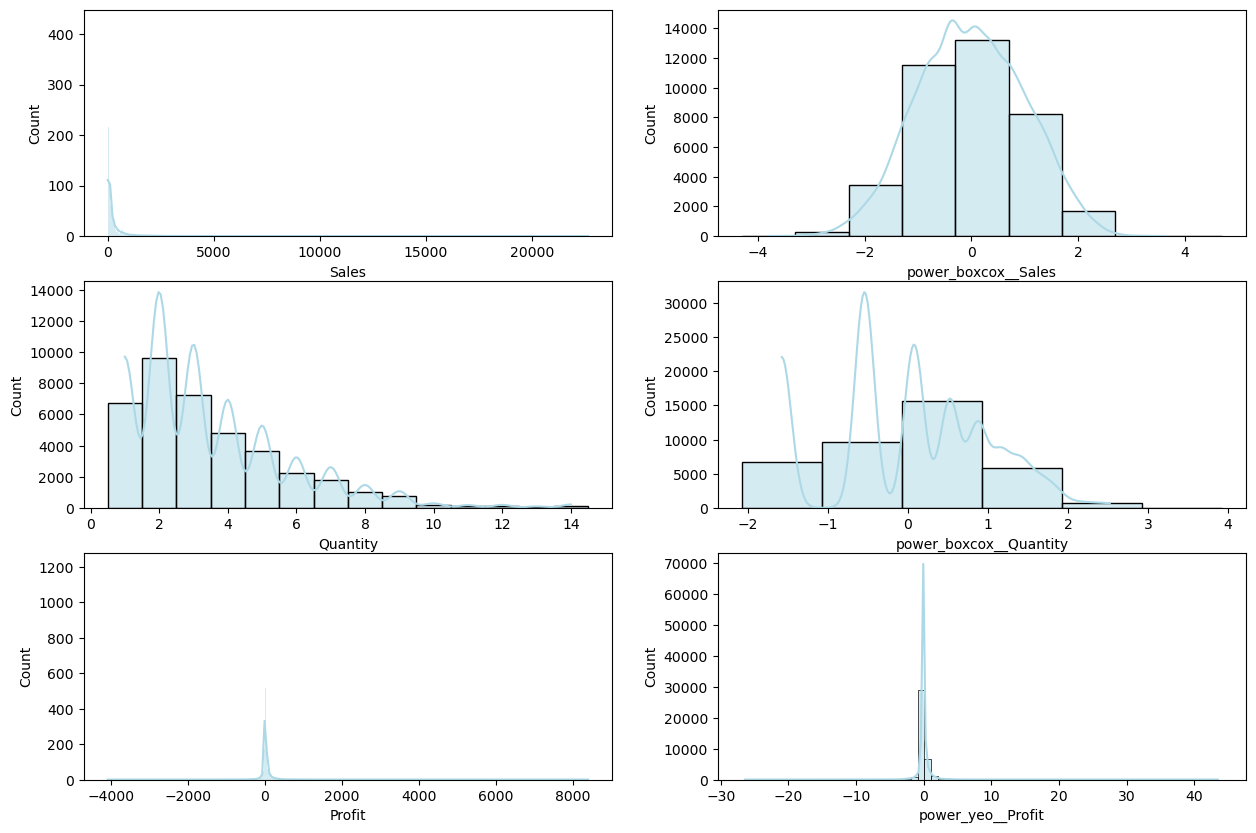

In [362]:
fig, ax = plt.subplots(3, 2, figsize=(15, 10))

### Sales
sns.histplot(x_train["Sales"], discrete = True, ax=ax[0,0], color="lightblue", kde=True)
sns.histplot(x_train_transformed_df["power_boxcox__Sales"], discrete = True, ax=ax[0,1], color="lightblue", kde=True)

### Quantity
sns.histplot(x_train["Quantity"], discrete = True, ax=ax[1,0],color="lightblue", kde=True)
sns.histplot(x_train_transformed_df["power_boxcox__Quantity"], discrete = True, ax=ax[1,1], color="lightblue", kde=True)


### Profit
sns.histplot(x_train["Profit"], ax=ax[2,0], discrete = True, color="lightblue", kde=True)
sns.histplot(x_train_transformed_df["power_yeo__Profit"], discrete = True, ax=ax[2,1], color="lightblue", kde=True)


### Transform Target

In [690]:
y_train_transformed = power_transformer_yeo_pipelines.fit_transform(y_train)

In [692]:
y_col_names = power_transformer_yeo_pipelines.get_feature_names_out()

In [694]:
y_train_transformed_df = array_to_df(y_train_transformed, y_col_names)

In [560]:
y_train_transformed_df.columns

Index(['proxy_returnrate'], dtype='object')

<Axes: xlabel='proxy_returnrate', ylabel='Count'>

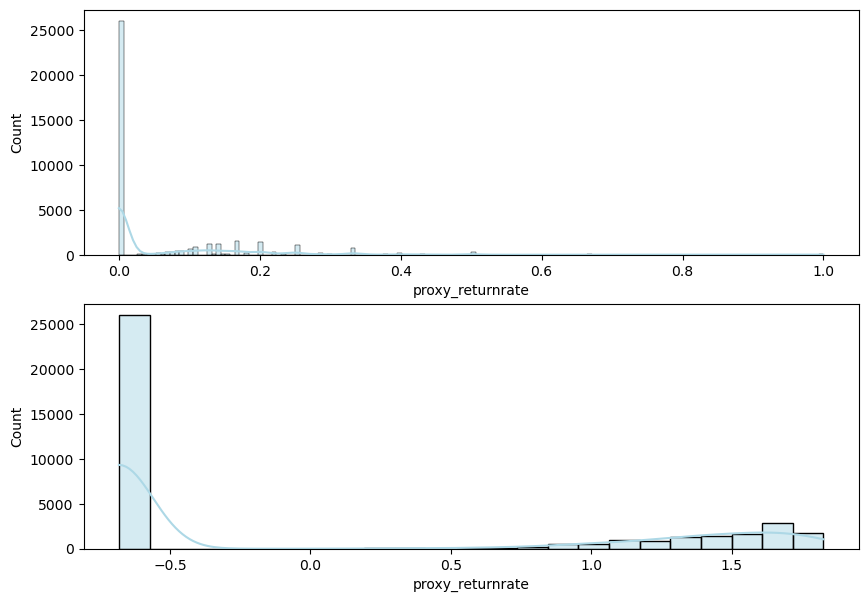

In [436]:
fig, ax = plt.subplots(2, figsize=(10, 7))

sns.histplot(y_train["proxy_returnrate"], ax=ax[0], color="lightblue", kde=True)
sns.histplot(y_train_transformed_df["proxy_returnrate"], ax=ax[1], color="lightblue", kde=True)

## Prepare Test-Set

### Transform Features

In [696]:
x_test, y_test = prepare_for_pipeline(test_df)

Original shape: (12824, 36)
Shape after dropna(): (12824, 14)
Shape after feature selection: (12824, 13)


In [698]:
x_test_transformed = col_transform_pipeline.fit_transform(x_test)

In [700]:
x_test_col_names = col_transform_pipeline.get_feature_names_out()

In [704]:
x_test_transformed_df = array_to_df(x_test_transformed.toarray(), x_test_col_names)

<Axes: xlabel='power_yeo__Profit', ylabel='Count'>

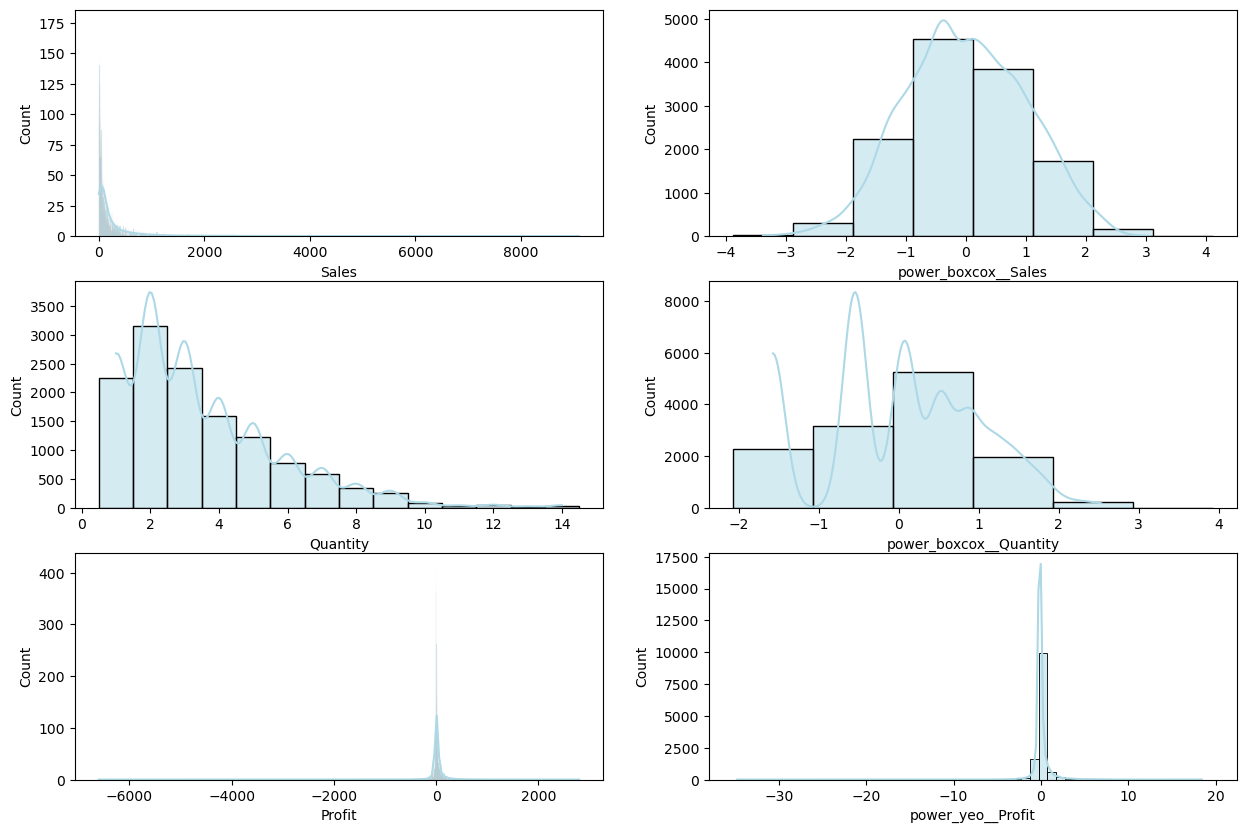

In [473]:
fig, ax = plt.subplots(3, 2, figsize=(15, 10))

### Sales
sns.histplot(x_test["Sales"], discrete = True, ax=ax[0,0], color="lightblue", kde=True)
sns.histplot(x_test_transformed_df["power_boxcox__Sales"], discrete = True, ax=ax[0,1], color="lightblue", kde=True)

### Quantity
sns.histplot(x_test["Quantity"], discrete = True, ax=ax[1,0],color="lightblue", kde=True)
sns.histplot(x_test_transformed_df["power_boxcox__Quantity"], discrete = True, ax=ax[1,1], color="lightblue", kde=True)


### Profit
sns.histplot(x_test["Profit"], ax=ax[2,0], discrete = True, color="lightblue", kde=True)
sns.histplot(x_test_transformed_df["power_yeo__Profit"], discrete = True, ax=ax[2,1], color="lightblue", kde=True)


### Transform Target

In [706]:
y_test_transformed = power_transformer_yeo_pipelines.fit_transform(y_test)

In [708]:
y_col_names = power_transformer_yeo_pipelines.get_feature_names_out()

In [710]:
y_test_transformed_df = array_to_df(y_test_transformed, y_col_names)

<Axes: xlabel='proxy_returnrate', ylabel='Count'>

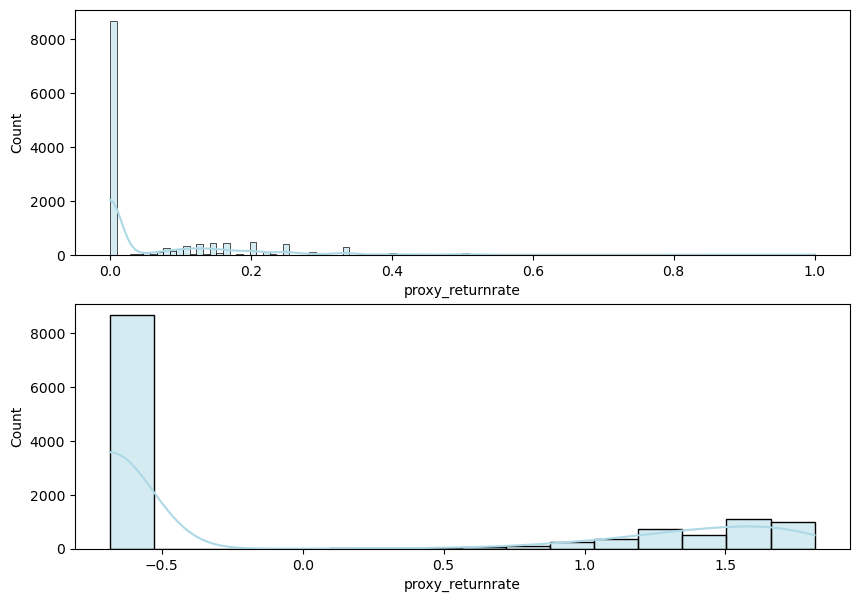

In [452]:
fig, ax = plt.subplots(2, figsize=(10, 7))

sns.histplot(y_test["proxy_returnrate"], ax=ax[0], color="lightblue", kde=True)
sns.histplot(y_test_transformed_df["proxy_returnrate"], ax=ax[1], color="lightblue", kde=True)

## Analysis

- Mit den aufbereiteten Trainingsdaten, setzen wir drei Modelle auf:

`Lineare Regression`
, `Entscheidungsbaum`
, `K-Nearest-Neighbor-Regression`


- Die Leistungen der Modelle auf den Trainingsdaten messen wir anhand des R-Quadrats. 
- Zudem nutzen wir die Crossvalidierung, um die Konsistenz der R-Quadrats-Werte zu prüfen.
- Zuletzt werden mithilfe von Hyperparameter-Optimierungen verschiedene Versionen der Modelle gebaut. Alle Versionen werden anschließend im Abschnitt `Preview` auf ihre Güte validiert.
    - Hierbei stößt das `Lineare Regression`-Modell auf Limitationen in der Auswahl an Parametern, die zu optimieren sind. Daher bleibt es bei der ersten aufgesetzten Version.

### Lineare Regression

In [712]:
lnreg = LinearRegression()
lnreg_m1 = lnreg.fit(x_train_transformed_df, y_train_transformed_df)
lnreg_m1.score(x_train_transformed_df, y_train_transformed_df)

0.13502794301636578

In [1335]:
lnreg_m1.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

#### Crossvalidation

In [391]:
lnreg_c_scores = cross_val_score(
    lnreg_m1, 
    x_train_transformed_df, 
    y_train_transformed_df, 
    scoring="r2", 
    cv=10
)

print("CV-Scores pro Fold:", lnreg_c_scores)
print(f"Durchschnittlicher CV-Score (R²): {lnreg_c_scores.mean():.3f}")

CV-Scores pro Fold: [0.11536359 0.12306983 0.12121393 0.1193706  0.12966552 0.13118076
 0.11559478 0.12193601 0.13301446 0.11839924]
Durchschnittlicher CV-Score (R²): 0.123


### Entscheidungsbäume

In [714]:
dtclass1 = DecisionTreeRegressor(max_depth=5)
dtclass_m1 = dtclass1.fit(x_train_transformed_df, y_train_transformed_df)
dtclass_m1_score = dtclass_m1.score(x_train_transformed_df, y_train_transformed_df)
dtclass_m1_score

0.13471427920588608

#### Hyperparametern validieren

In [1386]:
dtclass_parameter={
    
 "criterion":['squared_error','friedman_mse'],
  "splitter":['best','random'],
  "max_depth": [3, 5, 10, 15, 20, 25, 30, None],
  "max_features": ["sqrt", "log2", None],
  "min_samples_leaf": [2, 10, 30, 50],
  "min_impurity_decrease": [0],
  "ccp_alpha": [0.01]
}

In [1388]:
dtclass_regressor_cv = GridSearchCV(dtclass2,param_grid=dtclass_parameter,cv=10,scoring='neg_mean_squared_error')


In [1390]:
dtclass_regressor_cv.fit(x_train_transformed_df, y_train_transformed_df)

,estimator,DecisionTreeR...tter='random')
,param_grid,"{'ccp_alpha': [0.01], 'criterion': ['squared_error', 'friedman_mse'], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [716]:
dtclass2 = DecisionTreeRegressor(criterion="squared_error",max_depth=3 ,splitter="best", min_samples_split=2, min_samples_leaf=2, ccp_alpha= 0.01)
dtclass_m2 = dtclass2.fit(x_train_transformed_df, y_train_transformed_df)
dtclass_m2.score(x_train_transformed_df, y_train_transformed_df)

0.1109899062166898

#### Crossvalidation

In [397]:
dtclass_c_scores = cross_val_score(
    dtclass_m1, 
    x_train_transformed_df, 
    y_train_transformed_df, 
    scoring="r2", 
    cv=10
)

print("CV-Scores pro Fold:", dtclass_c_scores)
print(f"Durchschnittlicher CV-Score (R²): {dtclass_c_scores.mean():.3f}")

CV-Scores pro Fold: [0.11280904 0.1210439  0.12461754 0.11935782 0.12408252 0.1341789
 0.12022515 0.1232579  0.1300691  0.12025548]
Durchschnittlicher CV-Score (R²): 0.123


In [503]:
dtclass_c_scores2 = cross_val_score(
    dtclass_m2, 
    x_train_transformed_df, 
    y_train_transformed_df, 
    scoring="r2", 
    cv=10
)

print("CV-Scores pro Fold:", dtclass_c_scores2)
print(f"Durchschnittlicher CV-Score (R²): {dtclass_c_scores2.mean():.3f}")

CV-Scores pro Fold: [0.09984725 0.10882126 0.11006896 0.10952692 0.1108925  0.11296363
 0.1123854  0.1141035  0.1166229  0.10782354]
Durchschnittlicher CV-Score (R²): 0.110


### KNN

In [718]:
neigh = KNeighborsRegressor(n_neighbors=5)
neigh_m1 = neigh.fit(x_train_transformed_df, y_train_transformed_df)

neigh_m1_score = neigh_m1.score(x_train_transformed_df, y_train_transformed_df)
neigh_m1_score

0.3504072037802479

In [1414]:
n_num = [5, 10, 15, 20, 25]

cv_score = []

for n in n_num:
    n_neighbors_value = n

    neigh = KNeighborsRegressor(n_neighbors=n_neighbors_value)
    neigh_m2 = neigh.fit(x_train_transformed_df, y_train_transformed_df)

    neigh_c_scores = cross_val_score(
    neigh_m2, 
    x_train_transformed_df, 
    y_train_transformed_df, 
    scoring="r2", 
    cv=10
    )

    cv_score.append(neigh_c_scores.mean())

print(f"Durchschnittlicher CV-Score (R²): {cv_score}")

    

Durchschnittlicher CV-Score (R²): [-0.009518613421124334, 0.06041567366709005, 0.08352768620556875, 0.09305187959743264, 0.0988996862225752]


In [720]:
neigh = KNeighborsRegressor(n_neighbors=25)
neigh_m2 = neigh.fit(x_train_transformed_df, y_train_transformed_df)

neigh_m2.score(x_train_transformed_df, y_train_transformed_df)

0.17821431962448575

#### Crossvalidation

In [406]:
neigh_c_scores = cross_val_score(
    neigh_m2, 
    x_train_transformed_df, 
    y_train_transformed_df, 
    scoring="r2", 
    cv=10
)

print("CV-Scores pro Fold:", neigh_c_scores)
print(f"Durchschnittlicher CV-Score (R²): {neigh_c_scores.mean():.3f}")

CV-Scores pro Fold: [0.08357003 0.09337625 0.09357788 0.08845304 0.10410666 0.10044558
 0.07783123 0.09180361 0.10766754 0.08628819]
Durchschnittlicher CV-Score (R²): 0.093


**Note:**

---

Die Güte der folgenden Modelle werden mit den Testdaten im Abschnitt Preview auf den Messwerten R-Quadrat und RMSE validiert:

- Lineare Regression: `lnreg_m1`
- Entscheidungsbaum: `dtclass1`, `dtclass2`
- KNN: `neigh_m1`, `neigh_m2`

---

## Preview

### Lineare Regression

In [722]:
y_pred_lnreg = lnreg_m1.predict(x_test_transformed_df)

lnreg_c_scores_test = r2_score(y_test_transformed_df, y_pred_lnreg)
lnreg_rmse = np.sqrt(mean_squared_error(y_test_transformed_df, y_pred_lnreg))

print(f"R²: {lnreg_c_scores_test}")
print(f"RMSE: {lnreg_rmse}")

R²: 0.13372458408909105
RMSE: 0.9307391771656058


### Entscheidungsbäume

In [724]:
dtclass_m1_y_pred = dtclass_m1.predict(x_test_transformed_df)


dtclass_c_scores_test = r2_score(y_test_transformed_df, dtclass_m1_y_pred)
dtclass_rmse = np.sqrt(mean_squared_error(y_test_transformed_df, dtclass_m1_y_pred))

print(f"R²: {dtclass_c_scores_test}")
print(f"RMSE: {dtclass_rmse}")

R²: 0.12718923025628304
RMSE: 0.9342434210331465


In [726]:
dtclass_m2_y_pred = dtclass_m2.predict(x_test_transformed_df)


dtclass2_c_scores_test = r2_score(y_test_transformed_df, dtclass_m2_y_pred)
dtclass2_rmse = np.sqrt(mean_squared_error(y_test_transformed_df, dtclass_m2_y_pred))

print(f"R²: {dtclass2_c_scores_test}")
print(f"RMSE: {dtclass2_rmse}")

R²: 0.11347610722716162
RMSE: 0.9415539776204221


### KNN

In [728]:
neigh_y_pred = neigh_m1.predict(x_test_transformed_df)

neigh_c_scores_test = r2_score(y_test_transformed_df, neigh_y_pred)
neigh_rmse = np.sqrt(mean_squared_error(y_test_transformed_df, neigh_y_pred))

print(f"R²: {neigh_c_scores_test}")
print(f"RMSE: {neigh_rmse}")

R²: 0.016437903786363894
RMSE: 0.991746992036596


In [730]:
neigh_y_pred2 = neigh_m2.predict(x_test_transformed_df)

neigh_c_scores_test2 = r2_score(y_test_transformed_df, neigh_y_pred2)
neigh_rmse2 = np.sqrt(mean_squared_error(y_test_transformed_df, neigh_y_pred2))

print(f"R²: {neigh_c_scores_test2}")
print(f"RMSE: {neigh_rmse2}")

R²: 0.11168681779217526
RMSE: 0.942503677556658


**Note**:

---

Basierend auf den Ergebnissen mit den Testdaten, erweisen sich die folgenden Modelle als leistungsstärkste:

Lineare Regression: `lnreg_m1`
Entscheidungsbaum: `dtclass1`
KNN: `neigh_m2`

- Auf den ersten Blick, scheinen die Modelle jeweils sehr geringe R-Quadrat-Werte zu liefern. Außerdem liegen die RMSE-Werte nah an den Standardabweichungen des Targets und deuten auf sehr unpräzise Vorhersagen hin.
    - Die R-Quadrat- und RMSE-Werte unterscheiden sich minimal zwischen den Modellen.
 
- Im Kontext des Onlinehandels scheinen die Ergebnisse plausibel, da sich das Kaufverhalten von Nutzern schwer vorhersagen lässt, die Retouren als unregelmäßige Ereignisse mit sich bringen. Mit den limitierten Retourendaten steigerte sich die Herausforderung, für die Modelle treffende Vorhersagen zu liefern.

---

## Visualisation

### Ergebnisse der Modellen auf die Trainingsdaten

In [732]:
rsquares_scores = [lnreg_c_scores, dtclass_c_scores, neigh_c_scores]

rsquares_scores_dict = {
    "lnreg_c_scores": rsquares_scores[0].mean(),
    "dtclass_c_scores": rsquares_scores[1].mean(),
    "neigh_c_scores": rsquares_scores[2].mean()
}



In [734]:
rsquares_scores_training_df = pd.DataFrame(list(rsquares_scores_dict.items()), columns=["Modell", "Durchschnittliches R²"])

<Axes: >

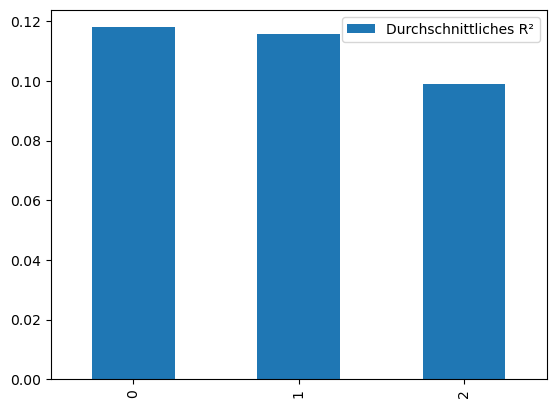

In [1450]:
rsquares_scores_training_df.plot.bar()

### Ergebnisse der Modellen auf die Test-Daten

In [736]:
rsquares_scores_test_dict = {
    "lnreg_c_scores_test": lnreg_c_scores_test,
    "dtclass_c_scores_test": dtclass_c_scores_test,
    "neigh_c_scores_test": neigh_c_scores_test2
}



In [738]:
rsquares_scores_test_df = pd.DataFrame(list(rsquares_scores_test_dict.items()), columns=["Modell", "R²"])

<Axes: >

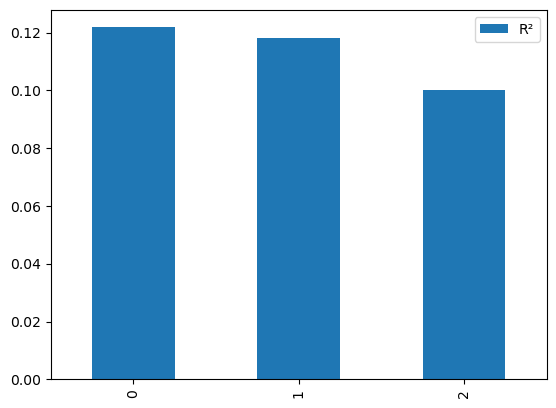

In [1460]:
rsquares_scores_test_df.plot.bar()

### Gütervalidierung

In [740]:
rmse_scores_test_dict = {
    "lnreg_rmse": lnreg_rmse,
    "dtclass_rmse": dtclass_rmse,
    "neigh_rmse2": neigh_rmse2
}



In [742]:
rmse_scores_test_dict_test_df = pd.DataFrame(list(rmse_scores_test_dict.items()), columns=["Modell", "Durchschnittliches R²"])

<Axes: >

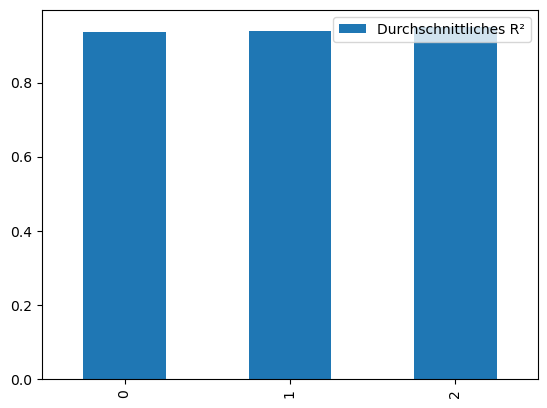

In [1466]:
rmse_scores_test_dict_test_df.plot.bar()

## Final Visualisation

### Verteilung des Targets

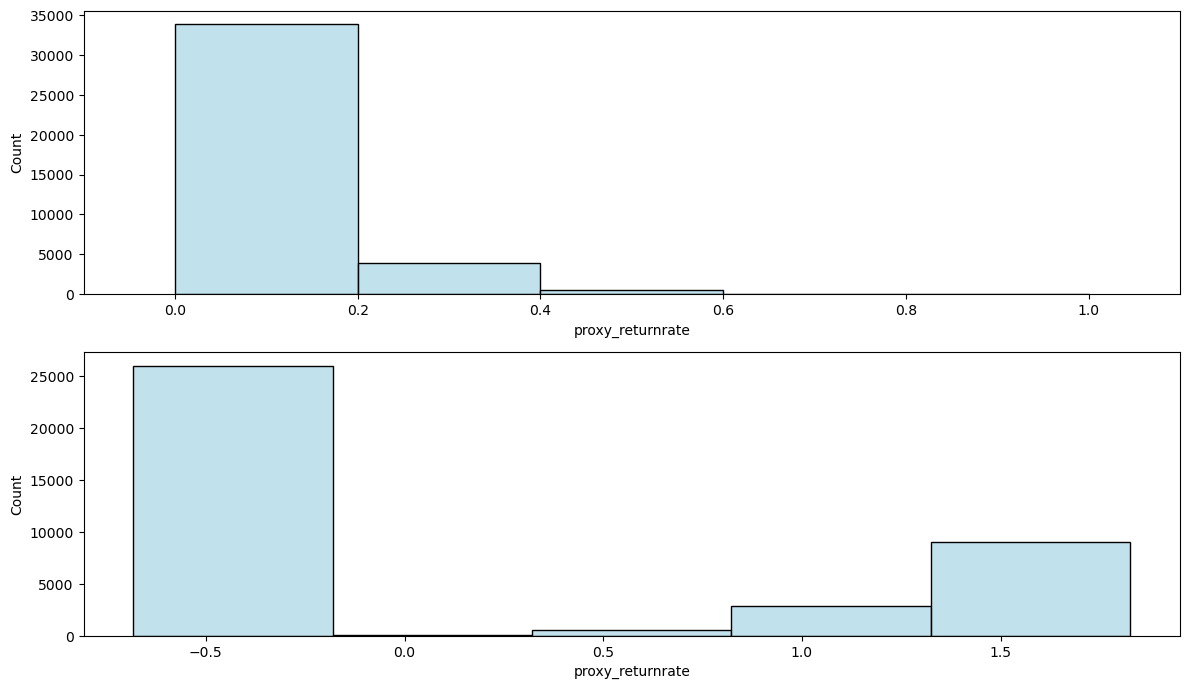

In [1077]:
fig, ax = plt.subplots(2, figsize=(12, 7))

sns.histplot(y_train["proxy_returnrate"], ax=ax[0], bins=5, color="lightblue")

min_val = y_train["proxy_returnrate"].min()
max_val = y_train["proxy_returnrate"].max()

ax[0].set_xlim([min_val - 0.1, max_val + 0.1])



sns.histplot(y_train_transformed_df["proxy_returnrate"], ax=ax[1], bins=5, color="lightblue")


plt.tight_layout()
plt.show()

### Ergebnisse der Modellen auf die Training und Test Daten

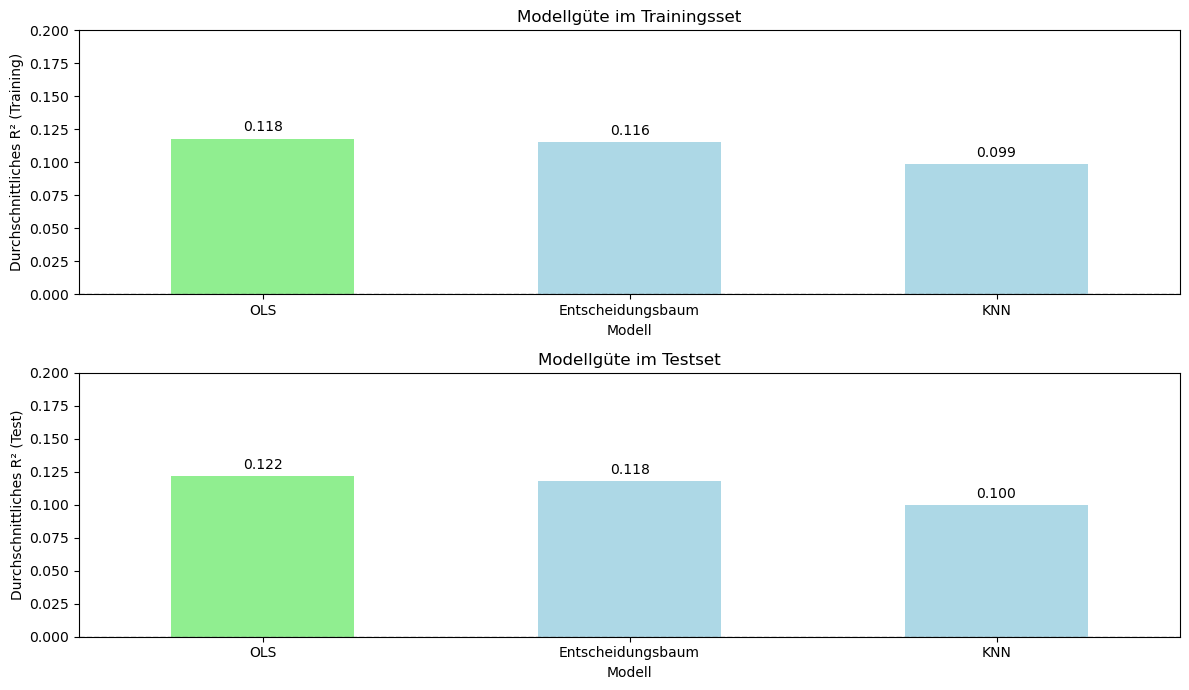

In [1490]:
fig, ax = plt.subplots(2, figsize=(12, 7))

rsquares_scores_training_df.plot.bar(ax=ax[0], color="lightblue",title="Modellgüte im Trainingsset", legend=False)
ax[0].set_xlabel("Modell")
ax[0].set_xticklabels(["OLS", "Entscheidungsbaum", "KNN"], rotation=0)
ax[0].patches[0].set_facecolor("lightgreen")
ax[0].bar_label(ax[0].containers[0], padding=3, fmt="%.3f")

ax[0].set_ylim([0, 0.2])
ax[0].set_ylabel("Durchschnittliches R² (Training)")
ax[0].axhline(0, color="grey", linestyle="--", linewidth=1)

#------------------

rsquares_scores_test_df.plot.bar(ax=ax[1], color="lightblue",title="Modellgüte im Testset", legend=False)
ax[1].set_xlabel("Modell")
ax[1].set_xticklabels(["OLS", "Entscheidungsbaum", "KNN"], rotation=0)
ax[1].patches[0].set_facecolor("lightgreen")
ax[1].bar_label(ax[1].containers[0], padding=3, fmt="%.3f")

ax[1].set_ylim([0, 0.2])
ax[1].set_ylabel("Durchschnittliches R² (Test)")
ax[1].axhline(0, color="grey", linestyle="--", linewidth=1)


plt.tight_layout()

plt.savefig(os.path.join(DOC_DIR,"modellguete_trainingset_testset.png"))

plt.show()

### RMSE-Score Ergebnisse

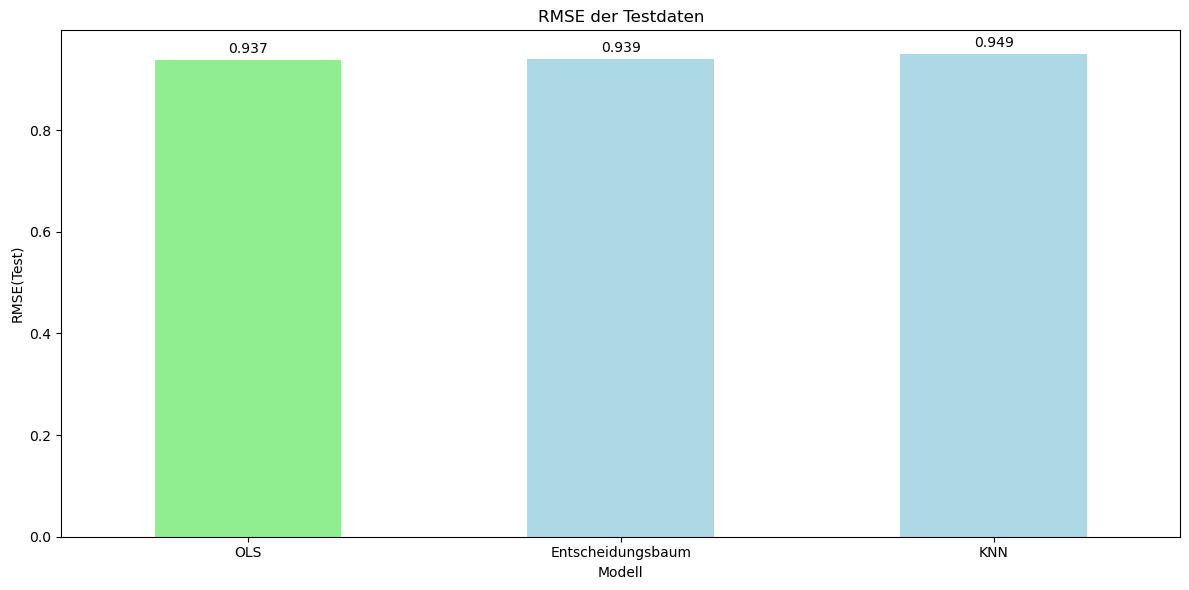

In [1492]:
fig, ax = plt.subplots(figsize=(12, 6))

rmse_scores_test_dict_test_df.plot.bar(
    ax=ax, color="lightblue", title="RMSE der Testdaten", legend=False
)

ax.set_xlabel("Modell")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["OLS", "Entscheidungsbaum", "KNN"], rotation=0)

ax.bar_label(ax.containers[0], padding=3, fmt="%.3f")
ax.patches[0].set_facecolor("lightgreen")

ax.set_ylabel("RMSE(Test)")

plt.tight_layout()

plt.savefig(os.path.join(DOC_DIR,"rmse.png"))

plt.show()

### OLS Vorhersage

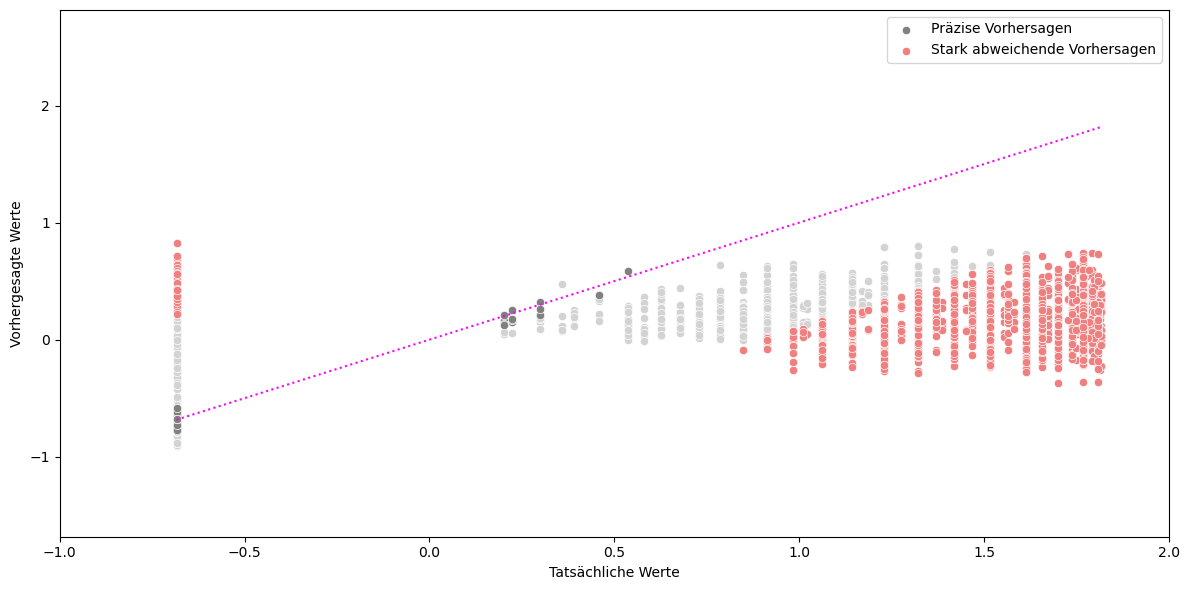

In [748]:
plt.figure(figsize=(12, 6))

results_01 = lnreg_m1.predict(x_test_transformed_df)
x_data = y_test_transformed_df.values.flatten()
y_data = np.array(y_pred_lnreg).flatten()

ax = sns.scatterplot(x=x_data, y=y_data, color="lightgrey")


delta = np.abs(y_data - x_data)
treffer_filter = delta < 0.1
x_gute_punkte = x_data[treffer_filter]
y_gute_punkte = y_data[treffer_filter]
sns.scatterplot(x=x_gute_punkte, y=y_gute_punkte, color="grey", ax=ax, label= "Präzise Vorhersagen")

schlechte_treffer_filter = delta > 0.90
x_extreme_punkte = x_data[schlechte_treffer_filter]
y_extreme_punkte = y_data[schlechte_treffer_filter]
sns.scatterplot(x=x_extreme_punkte, y=y_extreme_punkte, color="lightcoral", ax=ax, label= "Stark abweichende Vorhersagen")



min_val = x_data.min()
max_val = x_data.max()
ax.plot([min_val, max_val], [min_val, max_val], color="magenta", linestyle=":")
ax.set_xlim([min_val - 1, max_val + 1])
ax.set_ylim([min_val - 1, max_val + 1])

ax.set_xlim([-1.0, 2.0])
ax.set_xlabel("Tatsächliche Werte")
ax.set_ylabel("Vorhergesagte Werte")

plt.tight_layout()
plt.savefig(os.path.join(DOC_DIR,"ols_prediction.png"))

plt.show()